# Setup

In [1]:
from general import *
from experiments import *
from rendering import *

In [2]:
import shutil, os
# shutil.make_archive("../results", 'zip', "../results")

# Main

## Evaluate experiments

In [3]:
# Base experiments
for exp in tqdm(exps):
    evaluate_SMK(*exp, folder="../results/")

100%|██████████| 11/11 [00:35<00:00,  3.20s/it]


## Get values

In [4]:
metrics = ["F1", "accuracy", "jaccard", "dice"]
df = get_values(exps, metrics, "../results/")
df_ilp = get_values_ILP(["accuracy"], "../results_reg/")
df_reg = get_values(exps_reg, ["accuracy"], folder="../results_reg/")
df_reg = pd.concat([df_reg, df_ilp], ignore_index=True)
df.F1 *= 100
df.dice *= 100
df.accuracy *= 100
df_reg.accuracy *= 100

-> base-exact/structured.json
-> base-full/base_algo.json
-> base-full/structured.json
-> non-boolean-full/base_algo.json
-> non-boolean-full/structured.json
-> base-full/base_algo-heuristics.json
-> base-full/structured-heuristics.json
-> noisy-full/structured-naive.json
-> noisy-full/structured-lucb.json
-> noisy-full/base_algo-naive.json
-> noisy-full/base_algo-lucb.json
-> base-smallest/ILP.json
-> base-full/base_algo.json
-> base-full/structured.json
-> base-smallest/base_algo.json
-> base-smallest/structured.json


In [5]:
models = (
    (Models.BASE.value, ""), 
    # (Models.BLACK_BOX.value, ""), 
    (Models.NON_BOOLEAN.value, ""), 
    (Models.NOISY.value, "lucb"), 
    (Models.NOISY.value, "naive"))

## Regressions

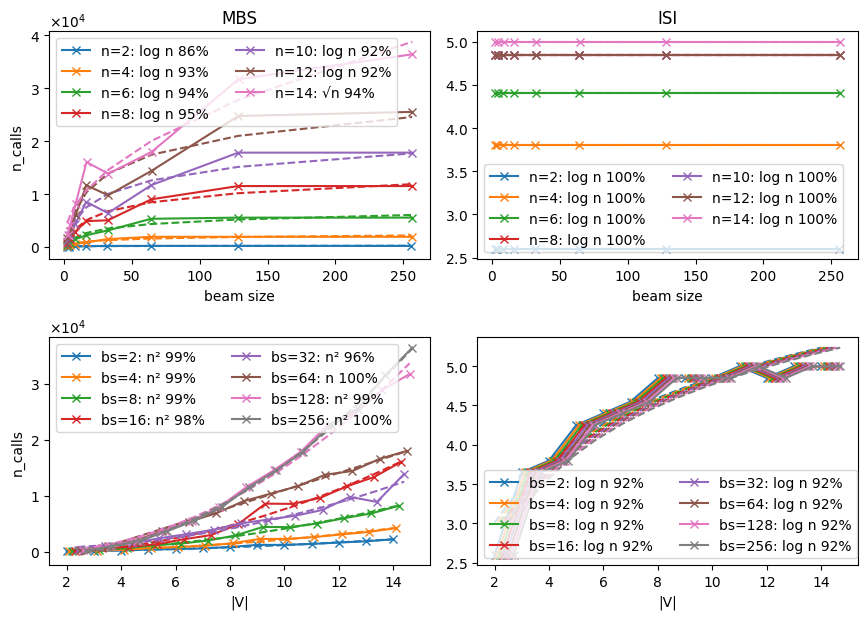

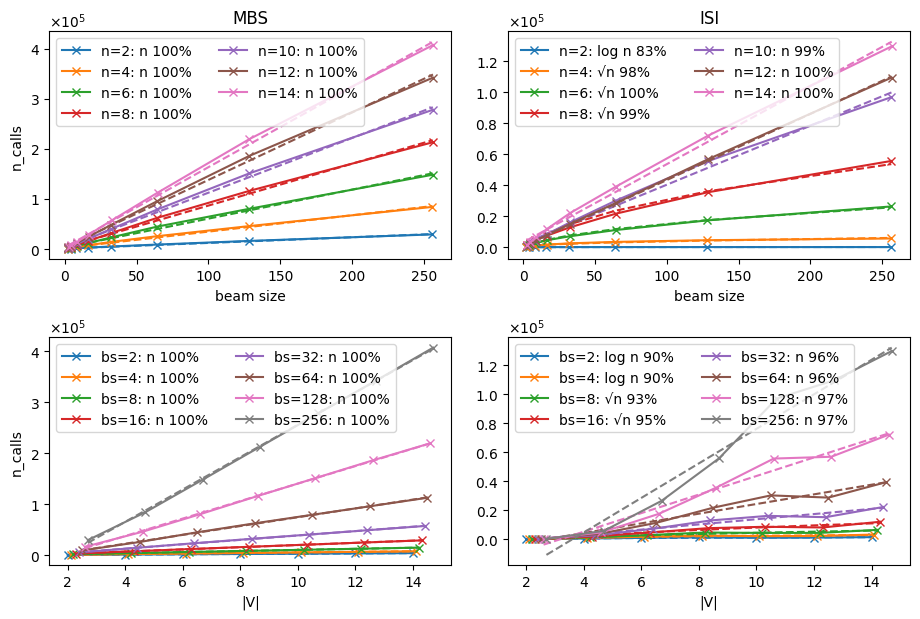

In [6]:
plot_all_regressions(df_reg, folder="../figures/")

## Tradeoff

/tmp/ipykernel_1529642/788686265.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_full_tradeoffs(pd.concat([df,df_reg]), "../figures/")


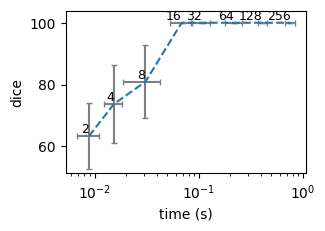

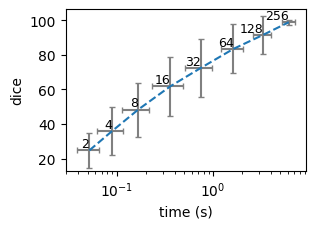

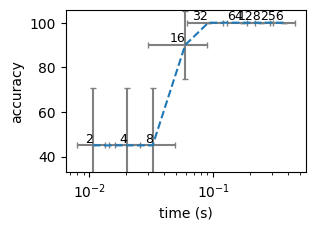

In [7]:
plot_full_tradeoffs(pd.concat([df,df_reg]), "../figures/")

## Algo comparisons

In [8]:
compare_algo(df, "ISI", "n_calls", "call_gain_ISI", "../tables/")

model      base non-boolean
n  bs                      
2  2    75 ± 43    40 ± 100
   4    82 ± 33     52 ± 82
   8    89 ± 22     67 ± 57
   16   93 ± 15     78 ± 40
   32    95 ± 9     85 ± 28
   64    97 ± 6     89 ± 21
   128   98 ± 3     93 ± 13
   256   99 ± 2      96 ± 8
5  2    38 ± 43      5 ± 62
   4    50 ± 31   -26 ± 111
   8    59 ± 25     15 ± 71
   16   70 ± 18     32 ± 47
   32   78 ± 14     45 ± 37
   64   82 ± 11     58 ± 26
   128  86 ± 10     64 ± 23
   256   89 ± 7     70 ± 19
10 2    61 ± 15     34 ± 36
   4    59 ± 14     -2 ± 91
   8    58 ± 16    -32 ± 98
   16   58 ± 15   -68 ± 229
   32   60 ± 14   -52 ± 132
   64   62 ± 11    -12 ± 80
   128  63 ± 10     -2 ± 62
   256   65 ± 8     33 ± 17

In [9]:
compare_algo(df, "ISI", "dice", "dice_gain_ISI", "../tables/")

model      base non-boolean
n  bs                      
2  2    37 ± 21     35 ± 27
   4    26 ± 25     26 ± 27
   8    19 ± 24     19 ± 25
   16     0 ± 0       0 ± 0
   32     0 ± 0       0 ± 0
   64     0 ± 0       0 ± 0
   128    0 ± 0       0 ± 0
   256    0 ± 0       0 ± 0
5  2    83 ± 17     83 ± 17
   4     87 ± 7      87 ± 6
   8     88 ± 8      89 ± 7
   16    85 ± 8      88 ± 7
   32    86 ± 9      85 ± 8
   64   87 ± 10     87 ± 10
   128  88 ± 14     88 ± 12
   256  82 ± 25     88 ± 17
10 2    22 ± 21     21 ± 21
   4    32 ± 26     32 ± 27
   8    44 ± 31     44 ± 32
   16   54 ± 36     55 ± 36
   32   60 ± 36     65 ± 36
   64   72 ± 31     71 ± 31
   128  79 ± 24     79 ± 25
   256   87 ± 8      86 ± 9

In [10]:
compare_algo(df, "lucb", "n_calls", "call_gain_LUCB", "../tables/")

algo   base_algo structured
n  bs                      
2  2    -20 ± 19    19 ± 10
   4    -20 ± 15    18 ± 11
   8    -19 ± 14    17 ± 12
   16   -26 ± 14    16 ± 13
   32   -38 ± 22    16 ± 14
   64   -51 ± 29    16 ± 14
   128  -30 ± 37    16 ± 14
   256   11 ± 27    16 ± 14
5  2      19 ± 5     18 ± 6
   4      19 ± 4     18 ± 5
   8      20 ± 0     17 ± 6
   16     20 ± 0     18 ± 6
   32     20 ± 0     18 ± 5
   64     20 ± 0     18 ± 5
   128    20 ± 0     18 ± 4
   256    20 ± 0     18 ± 3
10 2      20 ± 1    25 ± 15
   4      20 ± 0     26 ± 8
   8      20 ± 0     23 ± 9
   16     20 ± 0     21 ± 5
   32     20 ± 0     20 ± 3
   64     20 ± 0     19 ± 2
   128    20 ± 0     19 ± 2
   256    20 ± 0     19 ± 1

In [11]:
compare_algo(df, "lucb", "dice", "dice_gain_LUCB", "../tables/")

algo   base_algo structured
n  bs                      
2  2       4 ± 6     4 ± 10
   4       6 ± 5      4 ± 9
   8       9 ± 9     5 ± 10
   16    11 ± 12     5 ± 10
   32     6 ± 12     5 ± 10
   64     4 ± 12     4 ± 10
   128     3 ± 9     4 ± 10
   256     9 ± 7     4 ± 10
5  2       0 ± 1     -1 ± 4
   4      -0 ± 1      0 ± 0
   8       0 ± 1      0 ± 0
   16     -0 ± 1      0 ± 0
   32      0 ± 1      0 ± 0
   64     -0 ± 1      0 ± 0
   128    -0 ± 1      0 ± 0
   256     0 ± 2      0 ± 0
10 2       0 ± 0    -4 ± 13
   4      -0 ± 0    -5 ± 10
   8       0 ± 0     0 ± 12
   16      0 ± 0      1 ± 8
   32      0 ± 1     2 ± 12
   64      0 ± 1      4 ± 7
   128    -0 ± 1      4 ± 5
   256    -0 ± 1      4 ± 5

## Examples for text

In [12]:
locate_text_numbers(df)

base algo, base model, full, n=2:         bs:8->16:  +19.1 dice points
ISI algo, base model, full, n=10:         bs:8->16:  +13.5 dice points
base model, full, n=10, bs=4:             base->ISI: +86.9 dice points
base model, full, n=2, bs=256:            base->ISI: 99% less calls
base model, full, n=5, bs=2:              base->ISI: 40% less calls
non-boolean model, full, n=10, bs=16:     base->ISI: -68% less calls


## Metric means

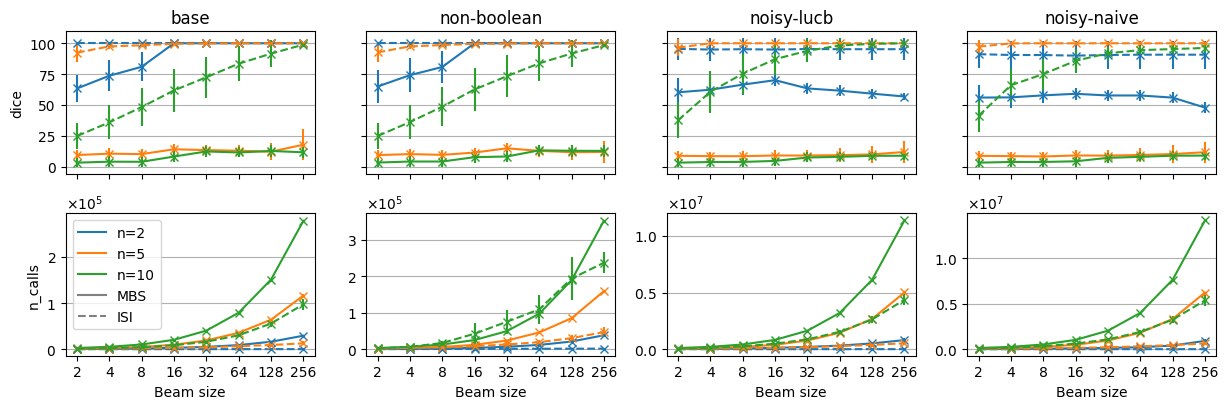

In [13]:
plot_metric_mean(df, models, ["dice", "n_calls"], [1], "../figures/")

## Smallest

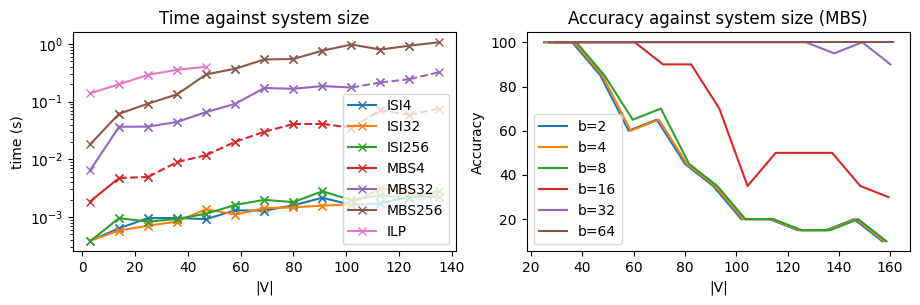

In [14]:
plot_smallest(df_reg, folder="../figures/")

## Heuristics

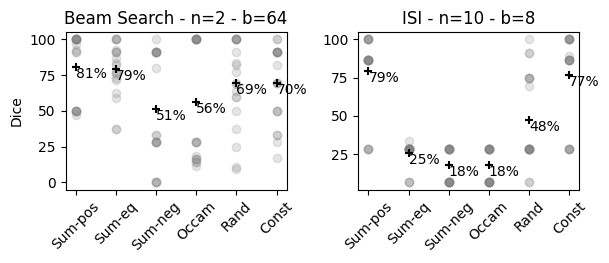

In [15]:
plot_heuristic(df, folder="../figures/")

## Runtime and n_calls for exact identification

In [16]:
print("Mean time (s) and number of calls for the exact identification")
df[df.exh == "exact"].groupby("n")[["time","n_calls"]].mean()

Mean time (s) and number of calls for the exact identification


,time,n_calls
n,,
2,0.014568,265.75
5,2.511013,52982.75
10,543.620598,3845386.85


In [17]:
print("Std time (s) and number of calls for the exact identification")
df[df.exh == "exact"].groupby("n")[["time","n_calls"]].std()

Std time (s) and number of calls for the exact identification


,time,n_calls
n,,
2,0.024060,540.581643
5,1.695073,33761.290746
10,136.597431,939931.736005
